In [10]:
import pandas as pd
import numpy as np

from statsmodels.formula.api import ols
from statsmodels.iolib.summary2 import summary_col # вывод результатов тестирования

from scipy.stats import f # f-распределение и критические значения
import matplotlib.pyplot as plt

# Не показывать Warning
import warnings
warnings.simplefilter(action='ignore', category=Warning)

In [2]:
# загрузим данные
df = pd.read_csv('sleep75.csv')
# спецификация модели
mod = ols(formula='sleep~1+totwrk+age+I(age**2)+smsa+male+south+marr+union', data=df)
# подгонка модели с ковариационной матрицей по умолчанию (неробастной)
res_ols = mod.fit()

res_ols.summary(slim=True, alpha=0.1)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sleep   R-squared:                       0.132
Model:                            OLS   Adj. R-squared:                  0.122
No. Observations:                 706   F-statistic:                     13.28
Covariance Type:            nonrobust   Prob (F-statistic):           5.93e-18
===============================================================================
                  coef    std err          t      P>|t|       [0.05       0.95]
-------------------------------------------------------------------------------
Intercept    3622.9849    219.646     16.495      0.000    3261.219    3984.751
totwrk         -0.1665      0.018     -9.128      0.000      -0.197      -0.136
age            -7.0388     11.232     -0.627      0.531     -25.538      11.461
I(age ** 2)     0.1190      0.134      0.886      0.376      -0.102       0.340
smsa          -53.5584     33.163     -1.615      0.107    -108.180       1.063
male           85.1892     34.924      2.439      0.015      27.668     142.711
south          99.8639     41.890      2.384      0.017      30.869     168.858
marr           32.9936     42.051      0.785      0.433     -36.267     102.254
union          14.0891     38.147      0.369      0.712     -48.741      76.919
===============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.98e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Через доверительный интервал можно проверить только одну гипотезу, а именно занчимость отдельного коэфицента. Если 0 принадлежит отрезку, то значит коэфицент незначим.

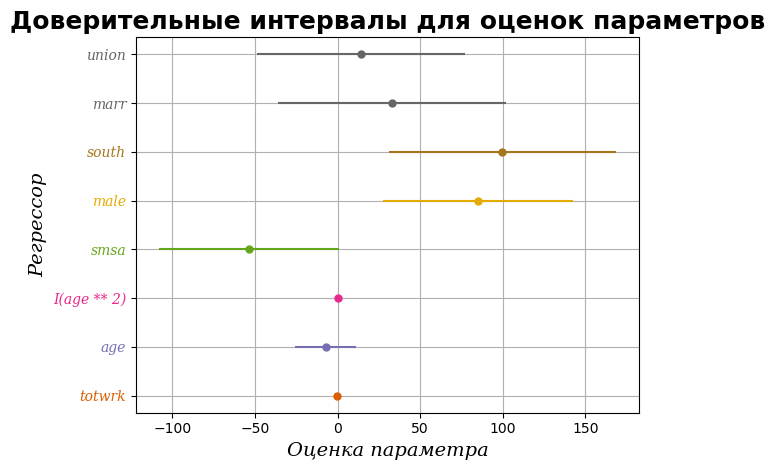

In [3]:
# спецификация модели
mod = ols(formula='sleep~1+totwrk+age+I(age**2)+smsa+male+south+marr+union', data=df)
# подгонка модели
res = mod.fit()

#plt.style.use('dark_background') # черный фон

conf_int = res.conf_int(alpha=0.1)
# Задаем палитру цветов для интервалов
colors = plt.cm.Dark2(np.linspace(0, 1, len(mod.exog_names)))
#colors = plt.cm.tab20(np.linspace(0, 1, len(mod.exog_names)))
# Построение графика
plt.figure()
for i in range(1, len(mod.exog_names)):
    plt.plot(res.params[i], i, marker='o', markersize=5, color=colors[i])  # Отмечаем оценки коэффициентов точками
    #plt.plot([conf_int.iloc[i, 0], conf_int.iloc[i, 1]], [i, i], marker='o', linestyle='', markersize=5, color=colors[i])  # Отмечаем границы доверительного интервала точками
    plt.hlines(y=i, xmin=conf_int.iloc[i, 0], xmax=conf_int.iloc[i, 1], color=colors[i])  # Соединяем границы интервала
    # Устанавливаем цвета для подписей оси y из списка цветов colors
    plt.gca().get_yticklabels()[i-1].set_color(colors[i])
plt.yticks(range(1, len(mod.exog_names)), mod.exog_names[1:], fontstyle='italic', family='serif') # подписи на оси y
plt.xlabel('Оценка параметра', fontsize=14, fontstyle='italic', family='serif')
plt.ylabel('Регрессор', fontsize=14, fontstyle='italic', family='serif')
plt.title('Доверительные интервалы для оценок параметров', fontsize=18, fontweight='bold')
plt.grid()
# оптимизируем поля и расположение объектов
plt.tight_layout()
# plt.vlines(x=0, ymin=1-0.3, ymax=len(mod.exog_names)-1+0.2, linestyles='dotted')
plt.show()

# 1 задача

In [45]:
# спецификация модели
#1.1 mod.1
mod = ols(formula='sleep~1+totwrk+age+I(age**2)+male+south+smsa+yngkid+marr+union', data=df)
# подгонка модели с ковариационной матрицей по умолчанию (неробастной)
res_ols = mod.fit()

res_ols.summary(slim=True, alpha=0.05)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sleep   R-squared:                       0.132
Model:                            OLS   Adj. R-squared:                  0.121
No. Observations:                 706   F-statistic:                     11.80
Covariance Type:            nonrobust   Prob (F-statistic):           2.12e-17
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    3638.2889    223.997     16.243      0.000    3198.498    4078.080
totwrk         -0.1667      0.018     -9.129      0.000      -0.203      -0.131
age            -7.6315     11.363     -0.672      0.502     -29.941      14.679
I(age ** 2)     0.1240      0.135      0.918      0.359      -0.141       0.389
male           86.6258     35.181      2.462      0.014      17.552     155.700
south         100.6078     41.969      2.397      0.017      18.207     183.009
smsa          -53.9046     33.199     -1.624      0.105    -119.086      11.277
yngkid        -17.9605     50.747     -0.354      0.724    -117.596      81.675
marr           34.9838     42.452      0.824      0.410     -48.365     118.333
union          13.3691     38.225      0.350      0.727     -61.682      88.420
===============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.06e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [46]:
# уровень значимости
sign_level= 0.05
# критическое значение
f.isf(q=sign_level, dfn=mod.df_model, dfd=mod.df_resid)

np.float64(1.8933165104204854)

# Регрессия значима 11.8 > 1.89

In [47]:
# подгонка модели с робастной HC3-оценкой ковариационной матрицы
res_hc = mod.fit(cov_type='HC3')
# уровень значимости
sign_level= 0.05
# робастная F-статистика и её P-значение и критическое значение
res_hc.fvalue, res_hc.f_pvalue, f.isf(q=sign_level, dfn=mod.df_model, dfd=mod.df_resid)

(9.871747635310403, 2.546285636605132e-14, np.float64(1.8933165104204854))

# робастная проверка Регрессия значима 9.87 > 1.89

In [49]:
# спецификация модели
#1.1 mod.2
mod = ols(formula='sleep~1+totwrk+age+I(age**2)+male+south+smsa+yngkid', data=df)
# подгонка модели с ковариационной матрицей по умолчанию (неробастной)
res_ols = mod.fit()

res_ols.summary(slim=True, alpha=0.05)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sleep   R-squared:                       0.131
Model:                            OLS   Adj. R-squared:                  0.123
No. Observations:                 706   F-statistic:                     15.09
Covariance Type:            nonrobust   Prob (F-statistic):           2.00e-18
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    3650.6731    223.367     16.344      0.000    3212.121    4089.225
totwrk         -0.1684      0.018     -9.279      0.000      -0.204      -0.133
age            -6.5813     11.292     -0.583      0.560     -28.751      15.588
I(age ** 2)     0.1118      0.134      0.833      0.405      -0.152       0.375
male           92.2555     34.571      2.669      0.008      24.380     160.131
south          98.1625     41.825      2.347      0.019      16.044     180.281
smsa          -57.0458     32.979     -1.730      0.084    -121.795       7.704
yngkid        -13.3664     50.178     -0.266      0.790    -111.885      85.152
===============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.05e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [50]:
# уровень значимости
sign_level= 0.05
# критическое значение
f.isf(q=sign_level, dfn=mod.df_model, dfd=mod.df_resid)

np.float64(2.0226806406648827)

# Регрессия значима 15.09 > 2.02

In [51]:
# подгонка модели с робастной HC3-оценкой ковариационной матрицы
res_hc = mod.fit(cov_type='HC3')
# уровень значимости
sign_level= 0.05
# робастная F-статистика и её P-значение и критическое значение
res_hc.fvalue, res_hc.f_pvalue, f.isf(q=sign_level, dfn=mod.df_model, dfd=mod.df_resid)

(12.595941951103027, 2.884796499359204e-15, np.float64(2.0226806406648827))

# робастная проверка Регрессия значима 12.6 > 2.02 

In [52]:
# спецификация модели
#1.1 mod.3
mod = ols(formula='sleep~1+totwrk+age+I(age**2)+male+south', data=df)
# подгонка модели с ковариационной матрицей по умолчанию (неробастной)
res_ols = mod.fit()

res_ols.summary(slim=True, alpha=0.05)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sleep   R-squared:                       0.128
Model:                            OLS   Adj. R-squared:                  0.121
No. Observations:                 706   F-statistic:                     20.49
Covariance Type:            nonrobust   Prob (F-statistic):           4.04e-19
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    3613.9947    218.433     16.545      0.000    3185.133    4042.856
totwrk         -0.1673      0.018     -9.228      0.000      -0.203      -0.132
age            -6.2547     11.191     -0.559      0.576     -28.227      15.718
I(age ** 2)     0.1089      0.134      0.814      0.416      -0.154       0.371
male           90.4567     34.257      2.641      0.008      23.198     157.716
south         114.5475     40.637      2.819      0.005      34.762     194.333
===============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.95e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [53]:
# уровень значимости
sign_level= 0.05
# критическое значение
f.isf(q=sign_level, dfn=mod.df_model, dfd=mod.df_resid)

np.float64(2.2269007504933973)

# Регрессия значима 20.49 > 2.23

In [56]:
# подгонка модели с робастной HC3-оценкой ковариационной матрицы
res_hc = mod.fit(cov_type='HC3')
# уровень значимости
sign_level= 0.05
# робастная F-статистика и её P-значение и критическое значение
res_hc.fvalue, res_hc.f_pvalue, f.isf(q=sign_level, dfn=mod.df_model, dfd=mod.df_resid)

(16.921086647161896, 8.2323955659398785e-16, np.float64(2.2269007504933973))

# робастная проверка Регрессия значима 16.92 > 2.23 

In [58]:
# спецификация модели
#1.1 mod.4
mod = ols(formula='sleep~1+smsa+yngkid+marr+union', data=df)
# подгонка модели с ковариационной матрицей по умолчанию (неробастной)
res_ols = mod.fit()

res_ols.summary(slim=True, alpha=0.05)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  sleep   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.002
No. Observations:                 706   F-statistic:                     1.314
Covariance Type:            nonrobust   Prob (F-statistic):              0.263
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3242.5212     44.044     73.620      0.000    3156.047    3328.995
smsa         -57.8898     34.293     -1.688      0.092    -125.219       9.439
yngkid       -31.1378     50.424     -0.618      0.537    -130.139      67.863
marr          60.0985     44.167      1.361      0.174     -26.617     146.814
union          7.3270     40.530      0.181      0.857     -72.247      86.901
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [59]:
# уровень значимости
sign_level= 0.05
# критическое значение
f.isf(q=sign_level, dfn=mod.df_model, dfd=mod.df_resid)

np.float64(2.384637913666586)

# Регрессия не значима 1.31 < 2.38

In [60]:
# подгонка модели с робастной HC3-оценкой ковариационной матрицы
res_hc = mod.fit(cov_type='HC3')
# уровень значимости
sign_level= 0.05
# робастная F-статистика и её P-значение и критическое значение
res_hc.fvalue, res_hc.f_pvalue, f.isf(q=sign_level, dfn=mod.df_model, dfd=mod.df_resid)

(1.4042008705487439, 0.23087483547408272, np.float64(2.384637913666586))

# робастная проверка Регрессия не значима 1.4 < 2.384 